# 01 — Data Preparation: Bubble Label Generation

This notebook generates **all bubble label variants** from two detection methods:

| Method | Source | Description |
|--------|--------|-------------|
| **GSADF** | `R/data_R/df_final_dataset201711_OLS.csv` *(OLS)* and `df_final_dataset201711_1.csv` *(V1)* | Pre-computed in R using the Phillips et al. (2015) rolling GSADF test. Two bubble-dating specifications. |
| **LPPLS** | `R/lppls_confidence.csv` | Daily positive-confidence from the Sornette LPPLS model. Needs thresholding + post-processing. |

### GSADF Variants (4)

| Variant | Source | Style |
|---------|--------|-------|
| `gsadf_ols` | OLS specification | Raw period flags from R |
| `gsadf_ols_period` | OLS | + gap-bridging (≤ 5 d) + min-duration (≥ 3 d) |
| `gsadf_v1` | Algorithm V1 specification | Raw period flags from R |
| `gsadf_v1_period` | V1 | + gap-bridging + min-duration |

### LPPLS Variants (6)

| Variant | Threshold | Style |
|---------|-----------|-------|
| `lppls_0.10` | conf ≥ 0.10 | Point-wise + trend filter |
| `lppls_0.10_period` | conf ≥ 0.10 | + smoothing + gap-bridging + min-duration |
| `lppls_0.05` | conf ≥ 0.05 | Point-wise + trend filter |
| `lppls_0.05_period` | conf ≥ 0.05 | + smoothing + gap-bridging + min-duration |
| `lppls_0.01` | conf ≥ 0.01 | Point-wise + trend filter |
| `lppls_0.01_period` | conf ≥ 0.01 | + smoothing + gap-bridging + min-duration |

### Output

A single file `outputs/all_labels.csv` — **single source of truth** for model training, with 10 label variants × 4 metals = 40 label columns.

In [1]:
import pandas as pd, numpy as np, os, warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs', exist_ok=True)

# ── Load base data (prices + macro features, 2017-05-10 →) ───────────────
df = pd.read_csv('../R/df_master.csv', sep=';', decimal=',', index_col=0)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ── Load two GSADF bubble-dating specifications ───────────────────────────
gsadf_ols = pd.read_csv('../R/data_R/df_final_dataset201711_OLS.csv',
                         sep=';', decimal=',', index_col=0)
gsadf_ols['Date'] = pd.to_datetime(gsadf_ols['Date'])

gsadf_v1  = pd.read_csv('../R/data_R/df_final_dataset201711_1.csv',
                          sep=';', decimal=',', index_col=0)
gsadf_v1['Date']  = pd.to_datetime(gsadf_v1['Date'])

# ── Merge GSADF BD columns into base data (left join → pre-2017-11 = 0) ──
BD_COLS = ['CODALY_BD', 'CUDALY_BD', 'LIDALY_BD', 'NIDALY_BD']

df = df.merge(
    gsadf_ols[['Date'] + BD_COLS].rename(columns={c: c + '_OLS' for c in BD_COLS}),
    on='Date', how='left')
df = df.merge(
    gsadf_v1[['Date'] + BD_COLS].rename(columns={c: c + '_V1' for c in BD_COLS}),
    on='Date', how='left')

for c in BD_COLS:
    df[c + '_OLS'] = df[c + '_OLS'].fillna(0).astype(int)
    df[c + '_V1']  = df[c + '_V1'].fillna(0).astype(int)

# ── Load cached LPPLS confidence ─────────────────────────────────────────
conf_df = pd.read_csv('../R/lppls_confidence.csv', index_col=0)

METALS = {
    'Cobalt':  'CODALY',
    'Copper':  'CUDALY',
    'Lithium': 'LIDALY',
    'Nickel':  'NIDALY',
}
TREND_LAG = 5

print(f'Base data : {df["Date"].min().date()} → {df["Date"].max().date()}  ({len(df)} rows)')
print(f'GSADF OLS : {gsadf_ols["Date"].min().date()} → {gsadf_ols["Date"].max().date()}  ({len(gsadf_ols)} rows)')
print(f'GSADF V1  : {gsadf_v1["Date"].min().date()} → {gsadf_v1["Date"].max().date()}  ({len(gsadf_v1)} rows)')
print(f'LPPLS conf: {len(conf_df)} rows  columns: {[c for c in conf_df.columns if "_conf" in c]}')


Base data : 2017-05-10 → 2025-10-31  (2152 rows)
GSADF OLS : 2017-11-01 → 2025-10-31  (2035 rows)
GSADF V1  : 2017-11-01 → 2025-10-31  (2035 rows)
LPPLS conf: 2152 rows  columns: ['CODALY_conf', 'CUDALY_conf', 'LIDALY_conf', 'NIDALY_conf']


## 1. GSADF Labels (from R)

Two specifications of the Phillips, Shi & Yu (2015) rolling **GSADF** test:
- **OLS** (`df_final_dataset201711_OLS.csv`): bubble dating using OLS-based critical values
- **V1** (`df_final_dataset201711_1.csv`): alternative bubble-dating algorithm

For each, we produce a **raw** version and a **period** version.  
The period version applies morphological post-processing to the binary flag:  
gap-bridging (fills short non-bubble gaps ≤ 5 d) + minimum duration filter (removes episodes < 3 d).

In [2]:
def count_episodes(arr):
    """Return (n_episodes, avg_length) for a binary array."""
    d = np.diff(np.concatenate([[0], arr, [0]]))
    starts = np.where(d == 1)[0]
    ends   = np.where(d == -1)[0]
    if len(starts) == 0:
        return 0, 0.0
    return len(starts), float(np.mean(ends - starts))


def apply_period_morphology(flag, max_gap=5, min_dur=3):
    """Bridge short gaps and remove very short episodes in a binary flag array."""
    flag = flag.copy().astype(int)
    n = len(flag)

    # Step 1: Bridge gaps <= max_gap
    i = 0
    while i < n:
        if flag[i] == 0:
            j = i
            while j < n and flag[j] == 0:
                j += 1
            if 0 < (j - i) <= max_gap and i > 0 and j < n:
                flag[i:j] = 1
            i = j
        else:
            i += 1

    # Step 2: Remove episodes shorter than min_dur
    i = 0
    while i < n:
        if flag[i] == 1:
            j = i
            while j < n and flag[j] == 1:
                j += 1
            if (j - i) < min_dur:
                flag[i:j] = 0
            i = j
        else:
            i += 1

    return flag


labels   = df[['Date']].copy()
MAX_GAP  = 5
MIN_DUR  = 3

print('GSADF bubble labels  (OLS and V1 specifications):')
print(f'{"Metal":10s}  {"Variant":24s}  {"Days":>5s}  {"Prev%":>6s}  {"Episodes":>8s}  {"Avg Len":>7s}')
print('-' * 68)

for metal, col in METALS.items():
    for spec, sfx in [('ols', '_OLS'), ('v1', '_V1')]:
        raw_arr    = df[f'{col}_BD{sfx}'].values.astype(int)
        period_arr = apply_period_morphology(raw_arr, MAX_GAP, MIN_DUR)
        for vname, arr in [(f'gsadf_{spec}', raw_arr),
                           (f'gsadf_{spec}_period', period_arr)]:
            labels[f'{metal}_{vname}'] = arr
            n     = int(arr.sum())
            n_ep, avg_l = count_episodes(arr)
            print(f'{metal:10s}  {vname:24s}  {n:5d}  {100*n/len(df):5.1f}%  '
                  f'{n_ep:8d}  {avg_l:6.1f}d')
    print()


GSADF bubble labels  (OLS and V1 specifications):
Metal       Variant                    Days   Prev%  Episodes  Avg Len
--------------------------------------------------------------------
Cobalt      gsadf_ols                   135    6.3%         8    16.9d
Cobalt      gsadf_ols_period            135    6.3%         8    16.9d
Cobalt      gsadf_v1                     76    3.5%        11     6.9d
Cobalt      gsadf_v1_period              77    3.6%         6    12.8d

Copper      gsadf_ols                    25    1.2%         2    12.5d
Copper      gsadf_ols_period             25    1.2%         2    12.5d
Copper      gsadf_v1                     31    1.4%         5     6.2d
Copper      gsadf_v1_period              27    1.3%         3     9.0d

Lithium     gsadf_ols                   466   21.7%         5    93.2d
Lithium     gsadf_ols_period            466   21.7%         5    93.2d
Lithium     gsadf_v1                    281   13.1%        36     7.8d
Lithium     gsadf_v1_period

## 2. LPPLS Labels

### Mathematical Foundation

The **Log-Periodic Power Law Singularity (LPPLS)** model (Sornette & Johansen 1995; Johansen, Ledoit & Sornette 2000) characterises a financial bubble as a log-price process that accelerates toward a finite-time singularity $t_c$:

$$\ln p(t) = A + B(t_c - t)^m \bigl[1 + C\cos\!\bigl(\omega\ln(t_c-t)+\phi\bigr)\bigr]$$

| Symbol | Interpretation | Viability range |
|--------|---------------|-----------------|
| $t_c$ | **Critical time** — anticipated peak or crash | $t_c > t$ |
| $A$ | Expected log-price at $t_c$ | — |
| $B < 0$ | **Power-law acceleration** coefficient | $B < 0$ |
| $m$ | **Power-law exponent** — degree of acceleration | $(0.01,\ 0.99)$ |
| $C$ | Oscillation amplitude | $|C| \leq 1$ |
| $\omega$ | **Log-periodic frequency** — oscillation speed in log-time | $(6,\ 13)$ |
| $\phi$ | Phase offset | $[0,\ 2\pi)$ |

**Intuition in two parts:**

1. **Power-law acceleration** $B(t_c-t)^m$: Because $B<0$ and $m\in(0,1)$, the term $(t_c-t)^m \to 0$ as $t\to t_c$, pushing $\ln p$ towards $A$. Prices therefore rise at an *accelerating* (super-exponential) rate — a signature of unsustainable momentum.

2. **Log-periodic oscillations** $B(t_c-t)^m C\cos(\omega\ln(t_c-t))$: Superimposed on the power-law trend are oscillations that *compress in calendar time* as $t_c$ nears. They capture herding dynamics: investors repeatedly overshoot and partially correct, yet the bubble trend reasserts each time. These ever-faster wiggles on a power-law ramp are the model's identifying signature.

**Simple example:** Cobalt gains 8 % in month 1, then 12 %, then 18 %, then 27 % — acceleration is the key signal. LPPLS fits a curve through a rolling window of log-prices, estimates $t_c$, and tells us how consistently that curve shape recurs across many windows starting at day $t$.

**Positive confidence score:**

$$\text{conf}(t) = \frac{\#\ \text{LPPLS fits satisfying all viability filters ending on day}\ t}{\text{total fits ending on day}\ t}$$

Viability filters enforce: $B<0$,\ $m\in(0.01,0.99)$,\ $\omega\in(6,13)$,\ $|C|\leq 1$,\ $\hat{t}_c > t$.  
A `conf` near 1 means almost every window fit agrees there is an active bubble trajectory; near 0 means no LPPLS bubble signal.

### 2a. Point-Wise Labels (thresholds: 0.10, 0.05, 0.01)

Day $t$ is labelled `bubble = 1` if **both** conditions hold:
1. $\text{conf}(t) \geq \theta$ for $\theta \in \{0.10,\ 0.05,\ 0.01\}$
2. $\text{price}(t) > \text{price}(t-5)$ *(trend filter — prices must actually be rising)*

In [3]:
LPPLS_THRESHOLDS = [0.10, 0.05, 0.01]

# ── Load LPPLS confidence (same row count and date order as df) ───────────
lppls_conf = {}
for metal, col in METALS.items():
    lppls_conf[metal] = (conf_df[col + '_conf'].values
                         if col + '_conf' in conf_df.columns
                         else np.zeros(len(df)))

print('LPPLS point-wise labels  (conf ≥ threshold  +  trend filter price[t] > price[t-5]):\n')
print(f'{"Metal":10s}', end='')
for thr in LPPLS_THRESHOLDS:
    print(f'   conf≥{thr:04.2f}', end='')
print()
print('-' * (10 + 14 * len(LPPLS_THRESHOLDS)))

for metal, col in METALS.items():
    conf   = lppls_conf[metal]
    prices = df[col].values
    print(f'{metal:10s}', end='')
    for thr in LPPLS_THRESHOLDS:
        flag = (conf >= thr).astype(int)
        for i in range(len(flag)):
            if flag[i] == 1 and i >= TREND_LAG:
                if prices[i] <= prices[i - TREND_LAG]:
                    flag[i] = 0
        vname = f'lppls_{thr:.2f}'
        labels[f'{metal}_{vname}'] = flag
        n    = int(flag.sum())
        n_ep, _ = count_episodes(flag)
        print(f'   {n:4d}d/{n_ep:2d}ep', end='')
    print()


LPPLS point-wise labels  (conf ≥ threshold  +  trend filter price[t] > price[t-5]):

Metal        conf≥0.10   conf≥0.05   conf≥0.01
----------------------------------------------------
Cobalt         53d/ 7ep     64d/ 8ep     64d/ 8ep
Copper        115d/25ep    143d/31ep    143d/31ep
Lithium        59d/12ep     83d/15ep     83d/15ep
Nickel        123d/27ep    129d/27ep    129d/27ep


## 3. LPPLS Period-Based Labels

Converts scattered daily LPPLS flags into coherent bubble **episodes** using a 4-step pipeline  
(Cao et al. 2025; Zhang et al. 2016; Shu & Zhu 2020).  Applied **separately** for each threshold (0.10, 0.05, 0.01):

1. **Smooth** raw confidence with a 5-day rolling mean
2. **Threshold** at conf ≥ θ + trend filter (price[t] > price[t-5])
3. **Bridge** gaps ≤ 5 days (morphological closing)
4. **Remove** episodes shorter than 3 days

In [4]:
SMOOTH_WINDOW = 5
MAX_GAP_P     = 5
MIN_DUR_P     = 3

print(f'Period pipeline: smooth={SMOOTH_WINDOW}d  thr=per-threshold  gap≤{MAX_GAP_P}d  min_dur≥{MIN_DUR_P}d\n')
print(f'{"Metal":10s}  {"Variant":24s}  {"Days":>5s}  {"Prev%":>6s}  {"Episodes":>8s}  {"Avg Len":>7s}')
print('-' * 68)

for metal, col in METALS.items():
    conf   = lppls_conf[metal]
    prices = df[col].values
    n      = len(conf)

    # Smooth once per metal (shared across thresholds)
    smoothed = pd.Series(conf).rolling(SMOOTH_WINDOW, min_periods=1).mean().values

    for thr in LPPLS_THRESHOLDS:
        # Step 1: Threshold + trend filter
        flag = (smoothed >= thr).astype(int)
        for i in range(n):
            if flag[i] == 1 and i >= TREND_LAG:
                if prices[i] <= prices[i - TREND_LAG]:
                    flag[i] = 0

        # Steps 2-3: Gap-bridging + short-episode removal
        flag = apply_period_morphology(flag, MAX_GAP_P, MIN_DUR_P)

        vname  = f'lppls_{thr:.2f}_period'
        labels[f'{metal}_{vname}'] = flag
        n_days = int(flag.sum())
        n_ep, avg_l = count_episodes(flag)
        print(f'{metal:10s}  {vname:24s}  {n_days:5d}  {100*n_days/len(df):5.1f}%  '
              f'{n_ep:8d}  {avg_l:6.1f}d')
    print()


Period pipeline: smooth=5d  thr=per-threshold  gap≤5d  min_dur≥3d

Metal       Variant                    Days   Prev%  Episodes  Avg Len
--------------------------------------------------------------------
Cobalt      lppls_0.10_period            56    2.6%         4    14.0d
Cobalt      lppls_0.05_period            71    3.3%         5    14.2d
Cobalt      lppls_0.01_period            92    4.3%         6    15.3d

Copper      lppls_0.10_period           125    5.8%        11    11.4d
Copper      lppls_0.05_period           179    8.3%        15    11.9d
Copper      lppls_0.01_period           203    9.4%        14    14.5d

Lithium     lppls_0.10_period            45    2.1%         6     7.5d
Lithium     lppls_0.05_period            73    3.4%        10     7.3d
Lithium     lppls_0.01_period           111    5.2%        10    11.1d

Nickel      lppls_0.10_period           140    6.5%        13    10.8d
Nickel      lppls_0.05_period           193    9.0%        10    19.3d
Nickel   

## 4. Summary Overview & Save

In [5]:
import matplotlib.pyplot as plt

# ── Ordered variant list: base then period for each method ────────────────
GSADF_VARIANTS = ['gsadf_ols', 'gsadf_ols_period', 'gsadf_v1', 'gsadf_v1_period']
LPPLS_VARIANTS = []
for t in LPPLS_THRESHOLDS:
    LPPLS_VARIANTS.extend([f'lppls_{t:.2f}', f'lppls_{t:.2f}_period'])
variant_names = GSADF_VARIANTS + LPPLS_VARIANTS

# ── Summary table ─────────────────────────────────────────────────────────
print('=' * 75)
print('SUMMARY: Bubble Days & Episodes per Metal × Label Variant')
print('=' * 75)
print(f'{"Metal":10s}  {"Variant":26s}  {"Days":>5s}  {"Prev%":>6s}  {"Eps":>4s}  {"AvgLen":>6s}')
print('-' * 68)

for metal in METALS:
    for v in variant_names:
        col_name = f'{metal}_{v}'
        if col_name in labels.columns:
            arr = labels[col_name].values
            n   = int(arr.sum())
            n_ep, avg_l = count_episodes(arr)
            print(f'{metal:10s}  {v:26s}  {n:5d}  {100*n/len(df):5.1f}%  '
                  f'{n_ep:4d}  {avg_l:5.1f}d')
    print()

# ── Build output DataFrame: Date + prices + macro features + labels ───────
price_cols = list(METALS.values())
macro_cols = [c for c in df.columns
              if c not in ['Date'] + price_cols and '_BD' not in c]

output = df[['Date'] + price_cols + macro_cols].copy()
for col in labels.columns:
    if col != 'Date':
        output[col] = labels[col].values

out_path = '../outputs/all_labels.csv'
output.to_csv(out_path, index=False)
print(f'Saved → {out_path}  ({os.path.getsize(out_path)/1024:.1f} KB)')
print(f'Columns: {len(output.columns)}  Rows: {len(output)}')
print(f'Label variants: {len(variant_names)} × 4 metals = {len(variant_names)*4} label columns')


SUMMARY: Bubble Days & Episodes per Metal × Label Variant
Metal       Variant                      Days   Prev%   Eps  AvgLen
--------------------------------------------------------------------
Cobalt      gsadf_ols                     135    6.3%     8   16.9d
Cobalt      gsadf_ols_period              135    6.3%     8   16.9d
Cobalt      gsadf_v1                       76    3.5%    11    6.9d
Cobalt      gsadf_v1_period                77    3.6%     6   12.8d
Cobalt      lppls_0.10                     53    2.5%     7    7.6d
Cobalt      lppls_0.10_period              56    2.6%     4   14.0d
Cobalt      lppls_0.05                     64    3.0%     8    8.0d
Cobalt      lppls_0.05_period              71    3.3%     5   14.2d
Cobalt      lppls_0.01                     64    3.0%     8    8.0d
Cobalt      lppls_0.01_period              92    4.3%     6   15.3d

Copper      gsadf_ols                      25    1.2%     2   12.5d
Copper      gsadf_ols_period               25    1.2%   

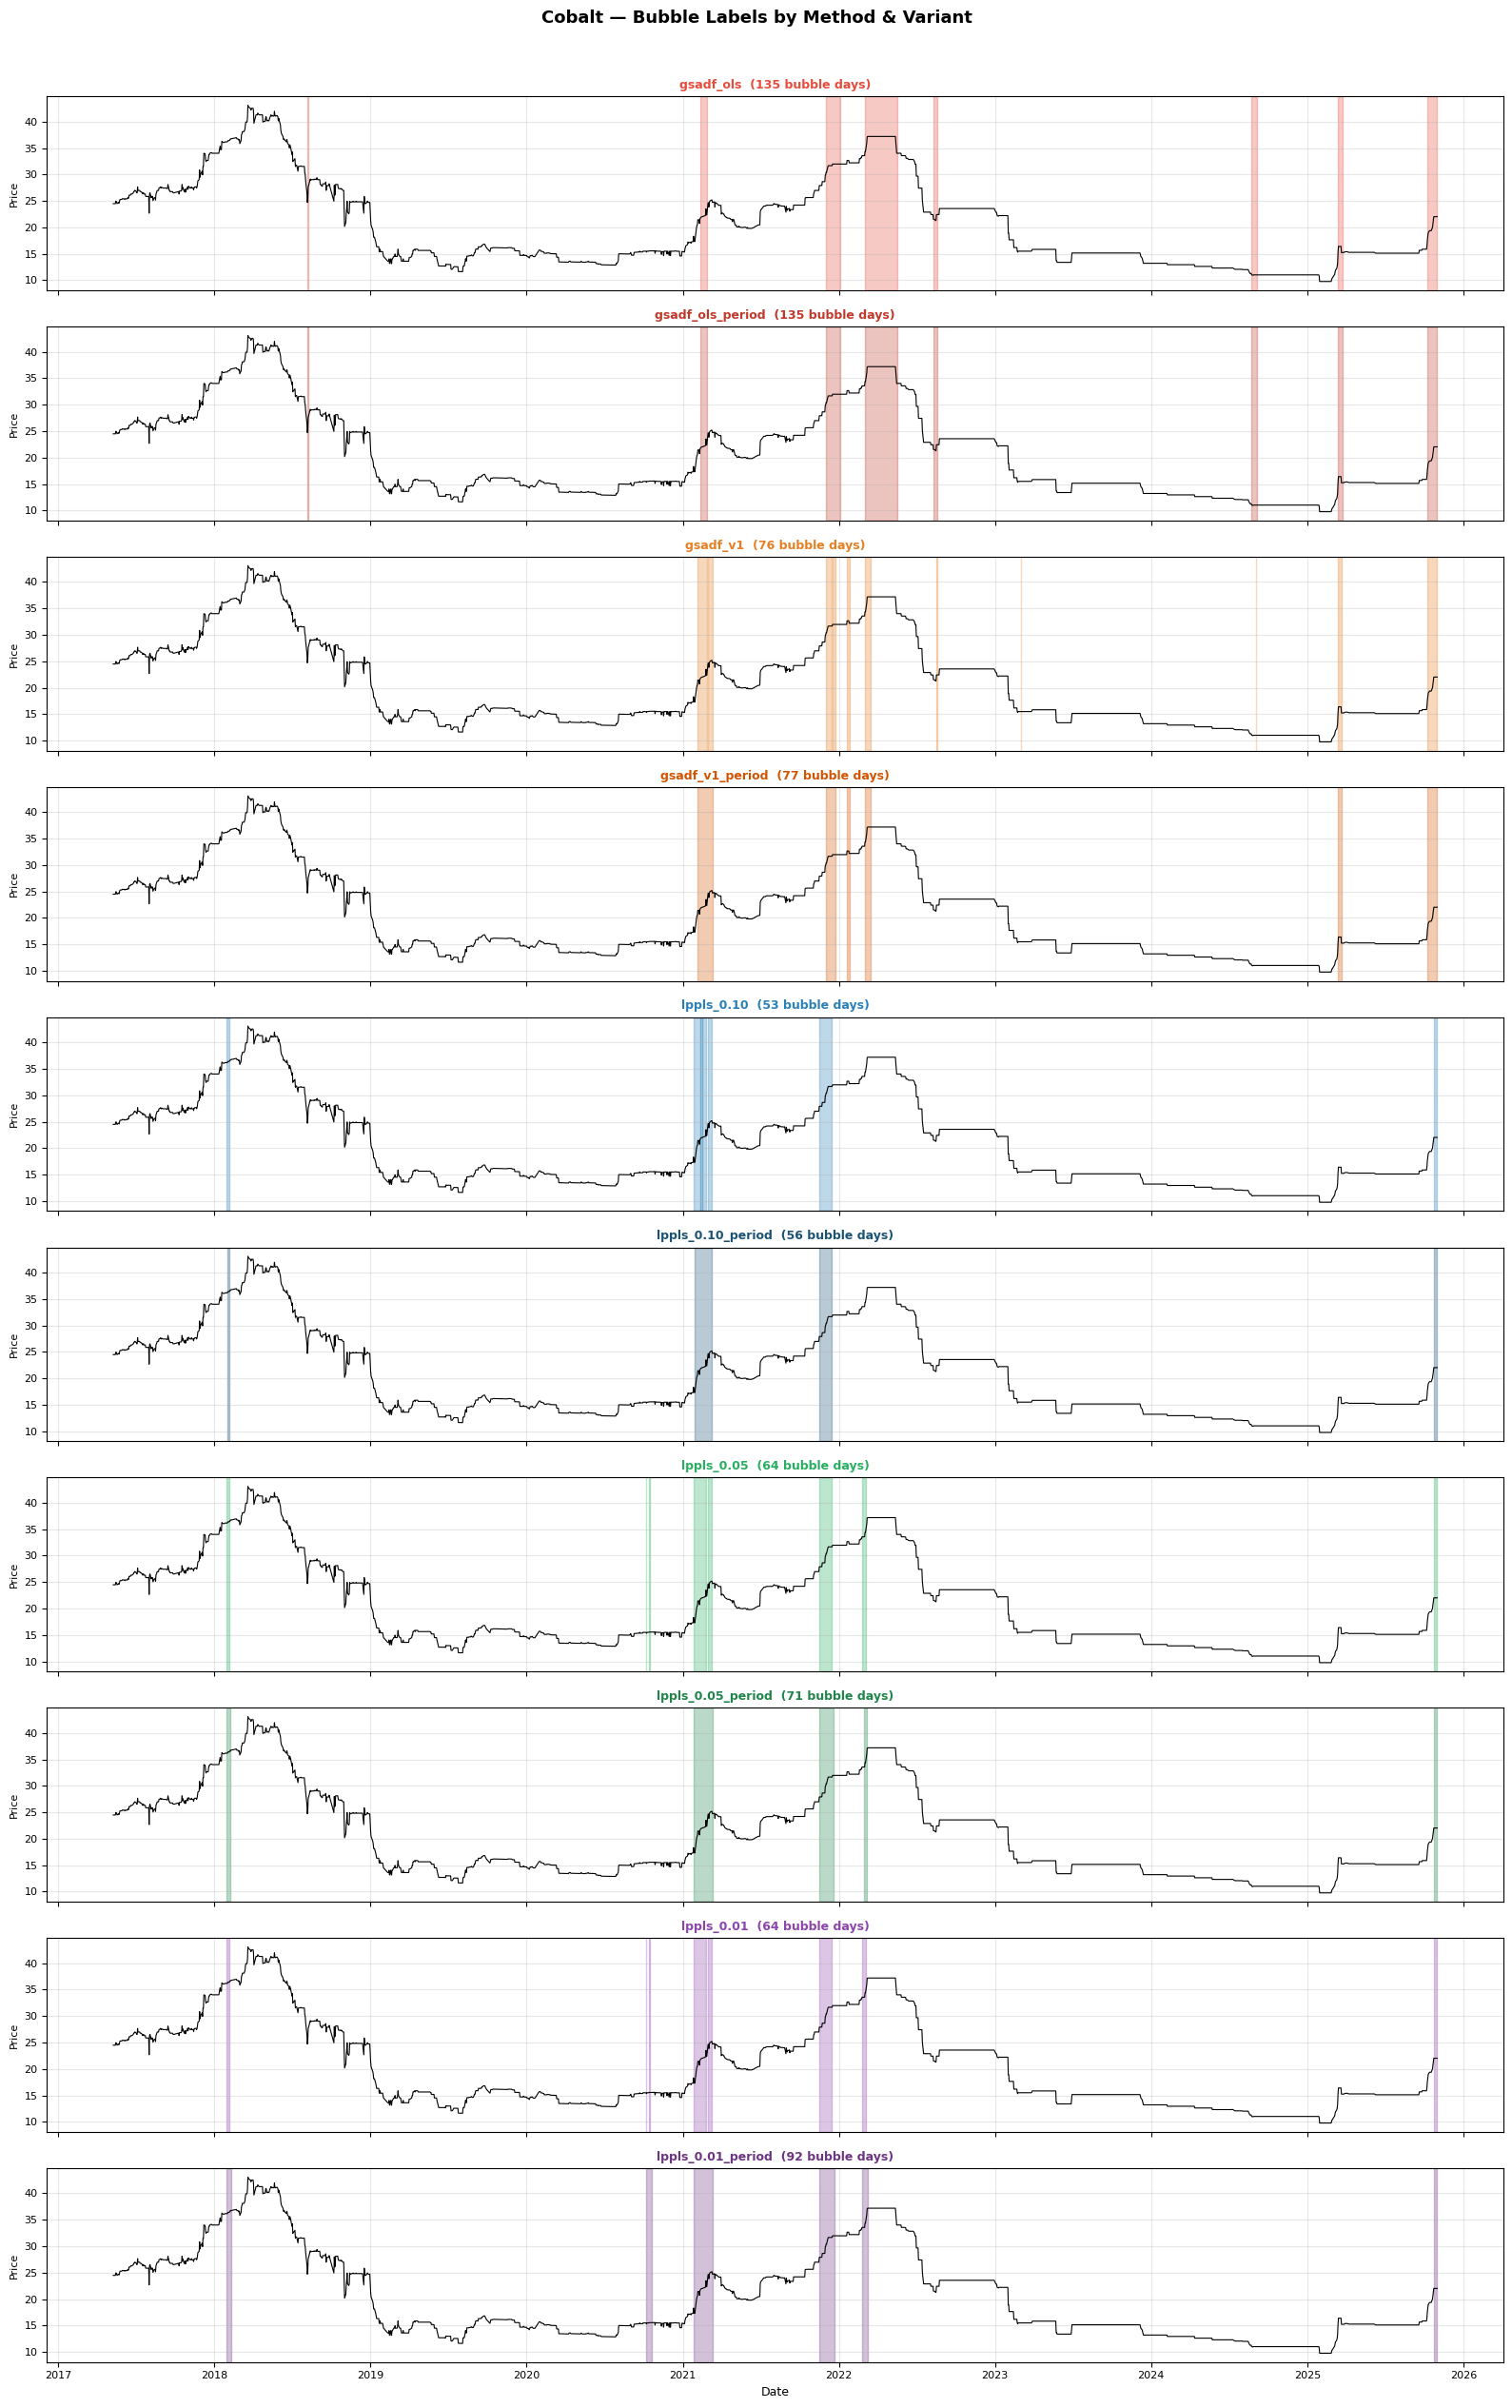

Saved → ../outputs/01_bubble_cobalt.png


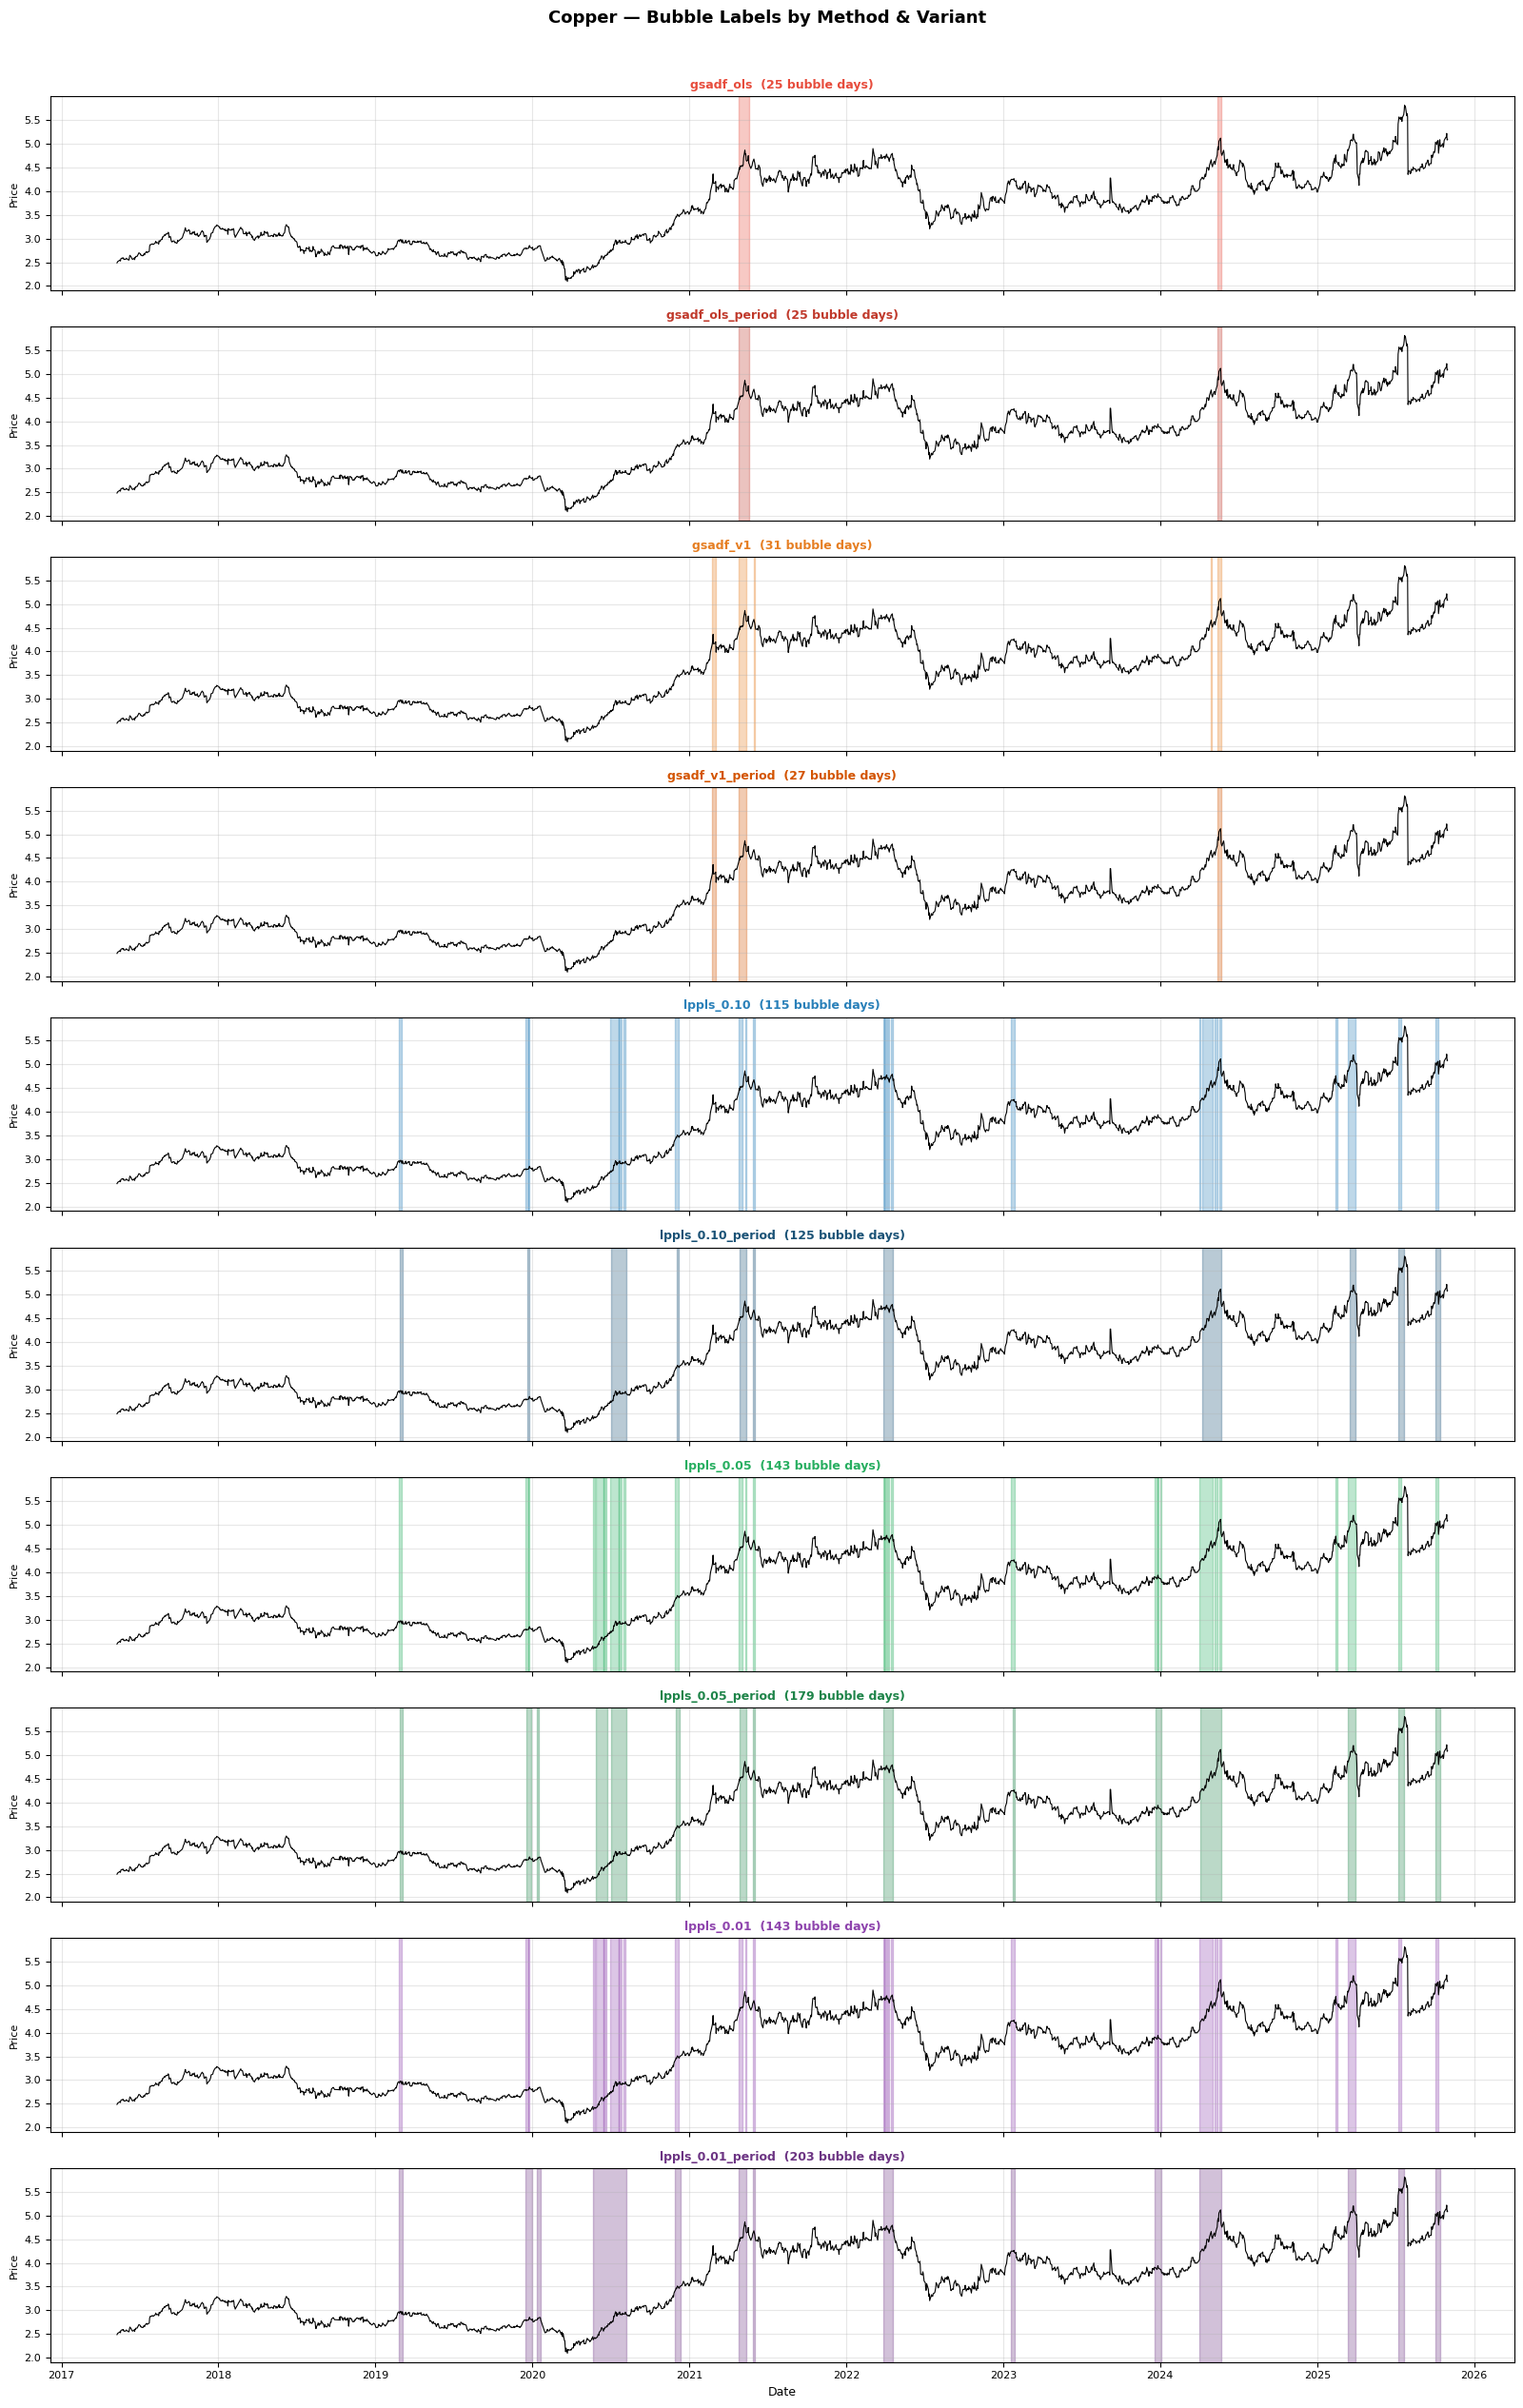

Saved → ../outputs/01_bubble_copper.png


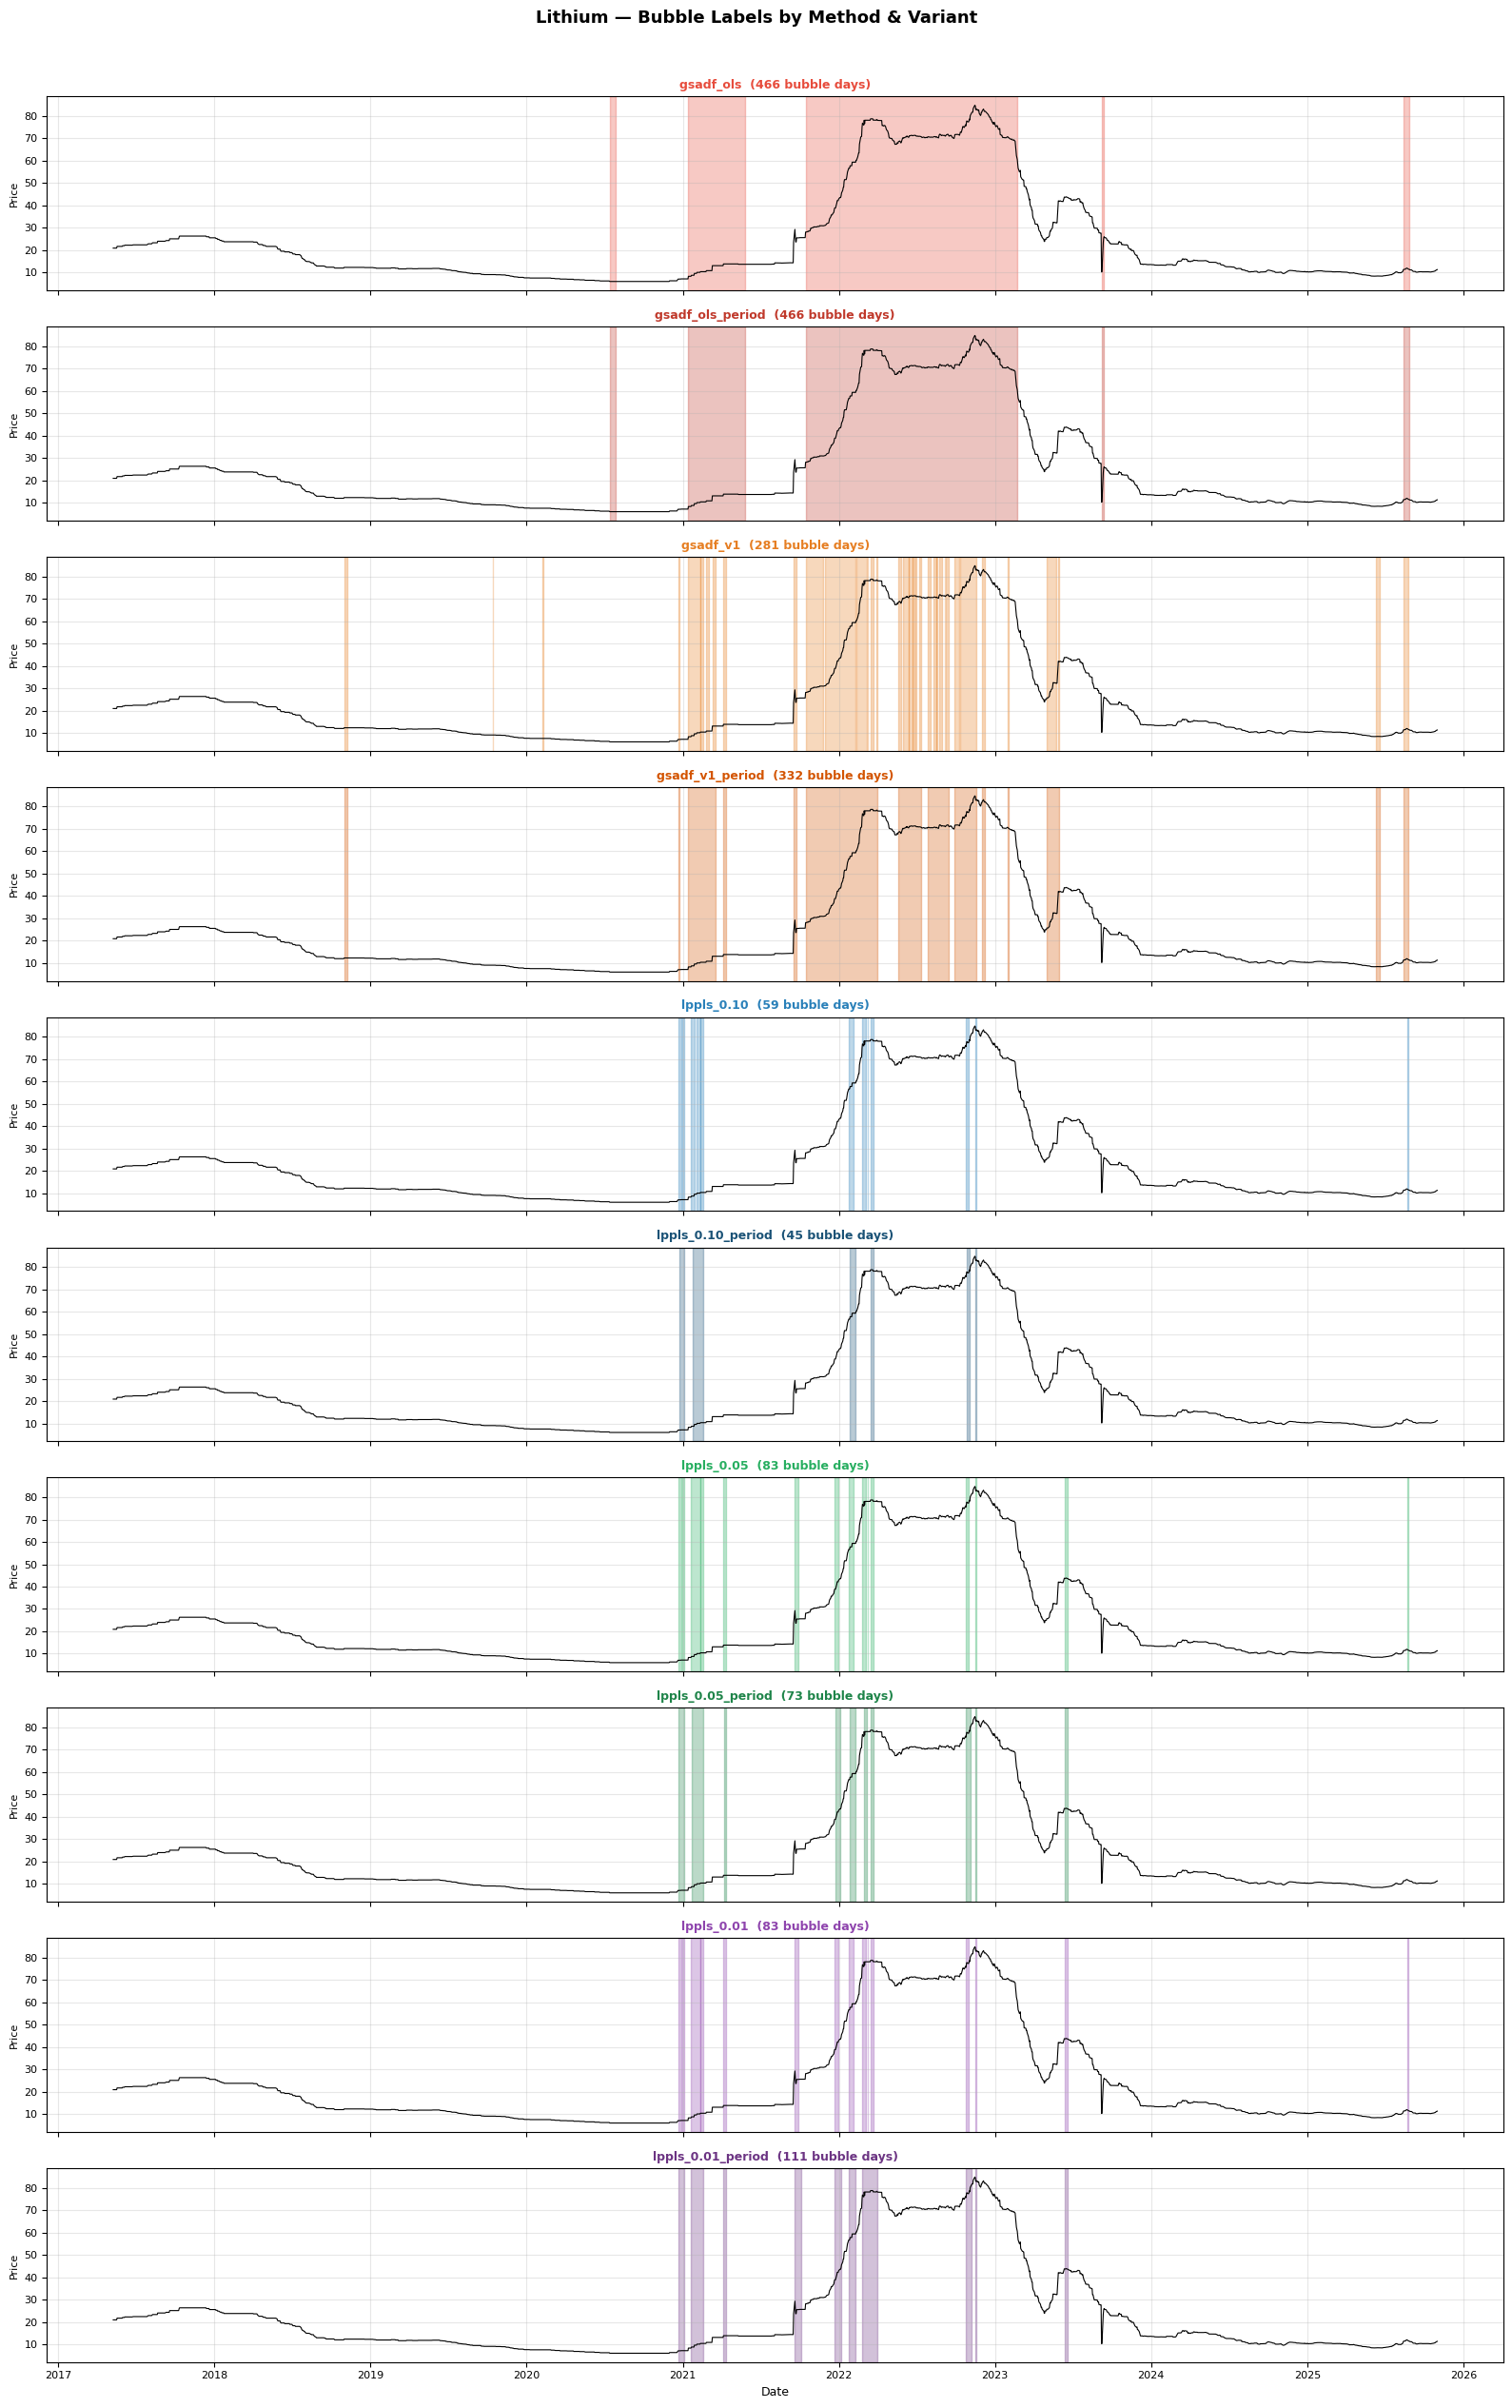

Saved → ../outputs/01_bubble_lithium.png


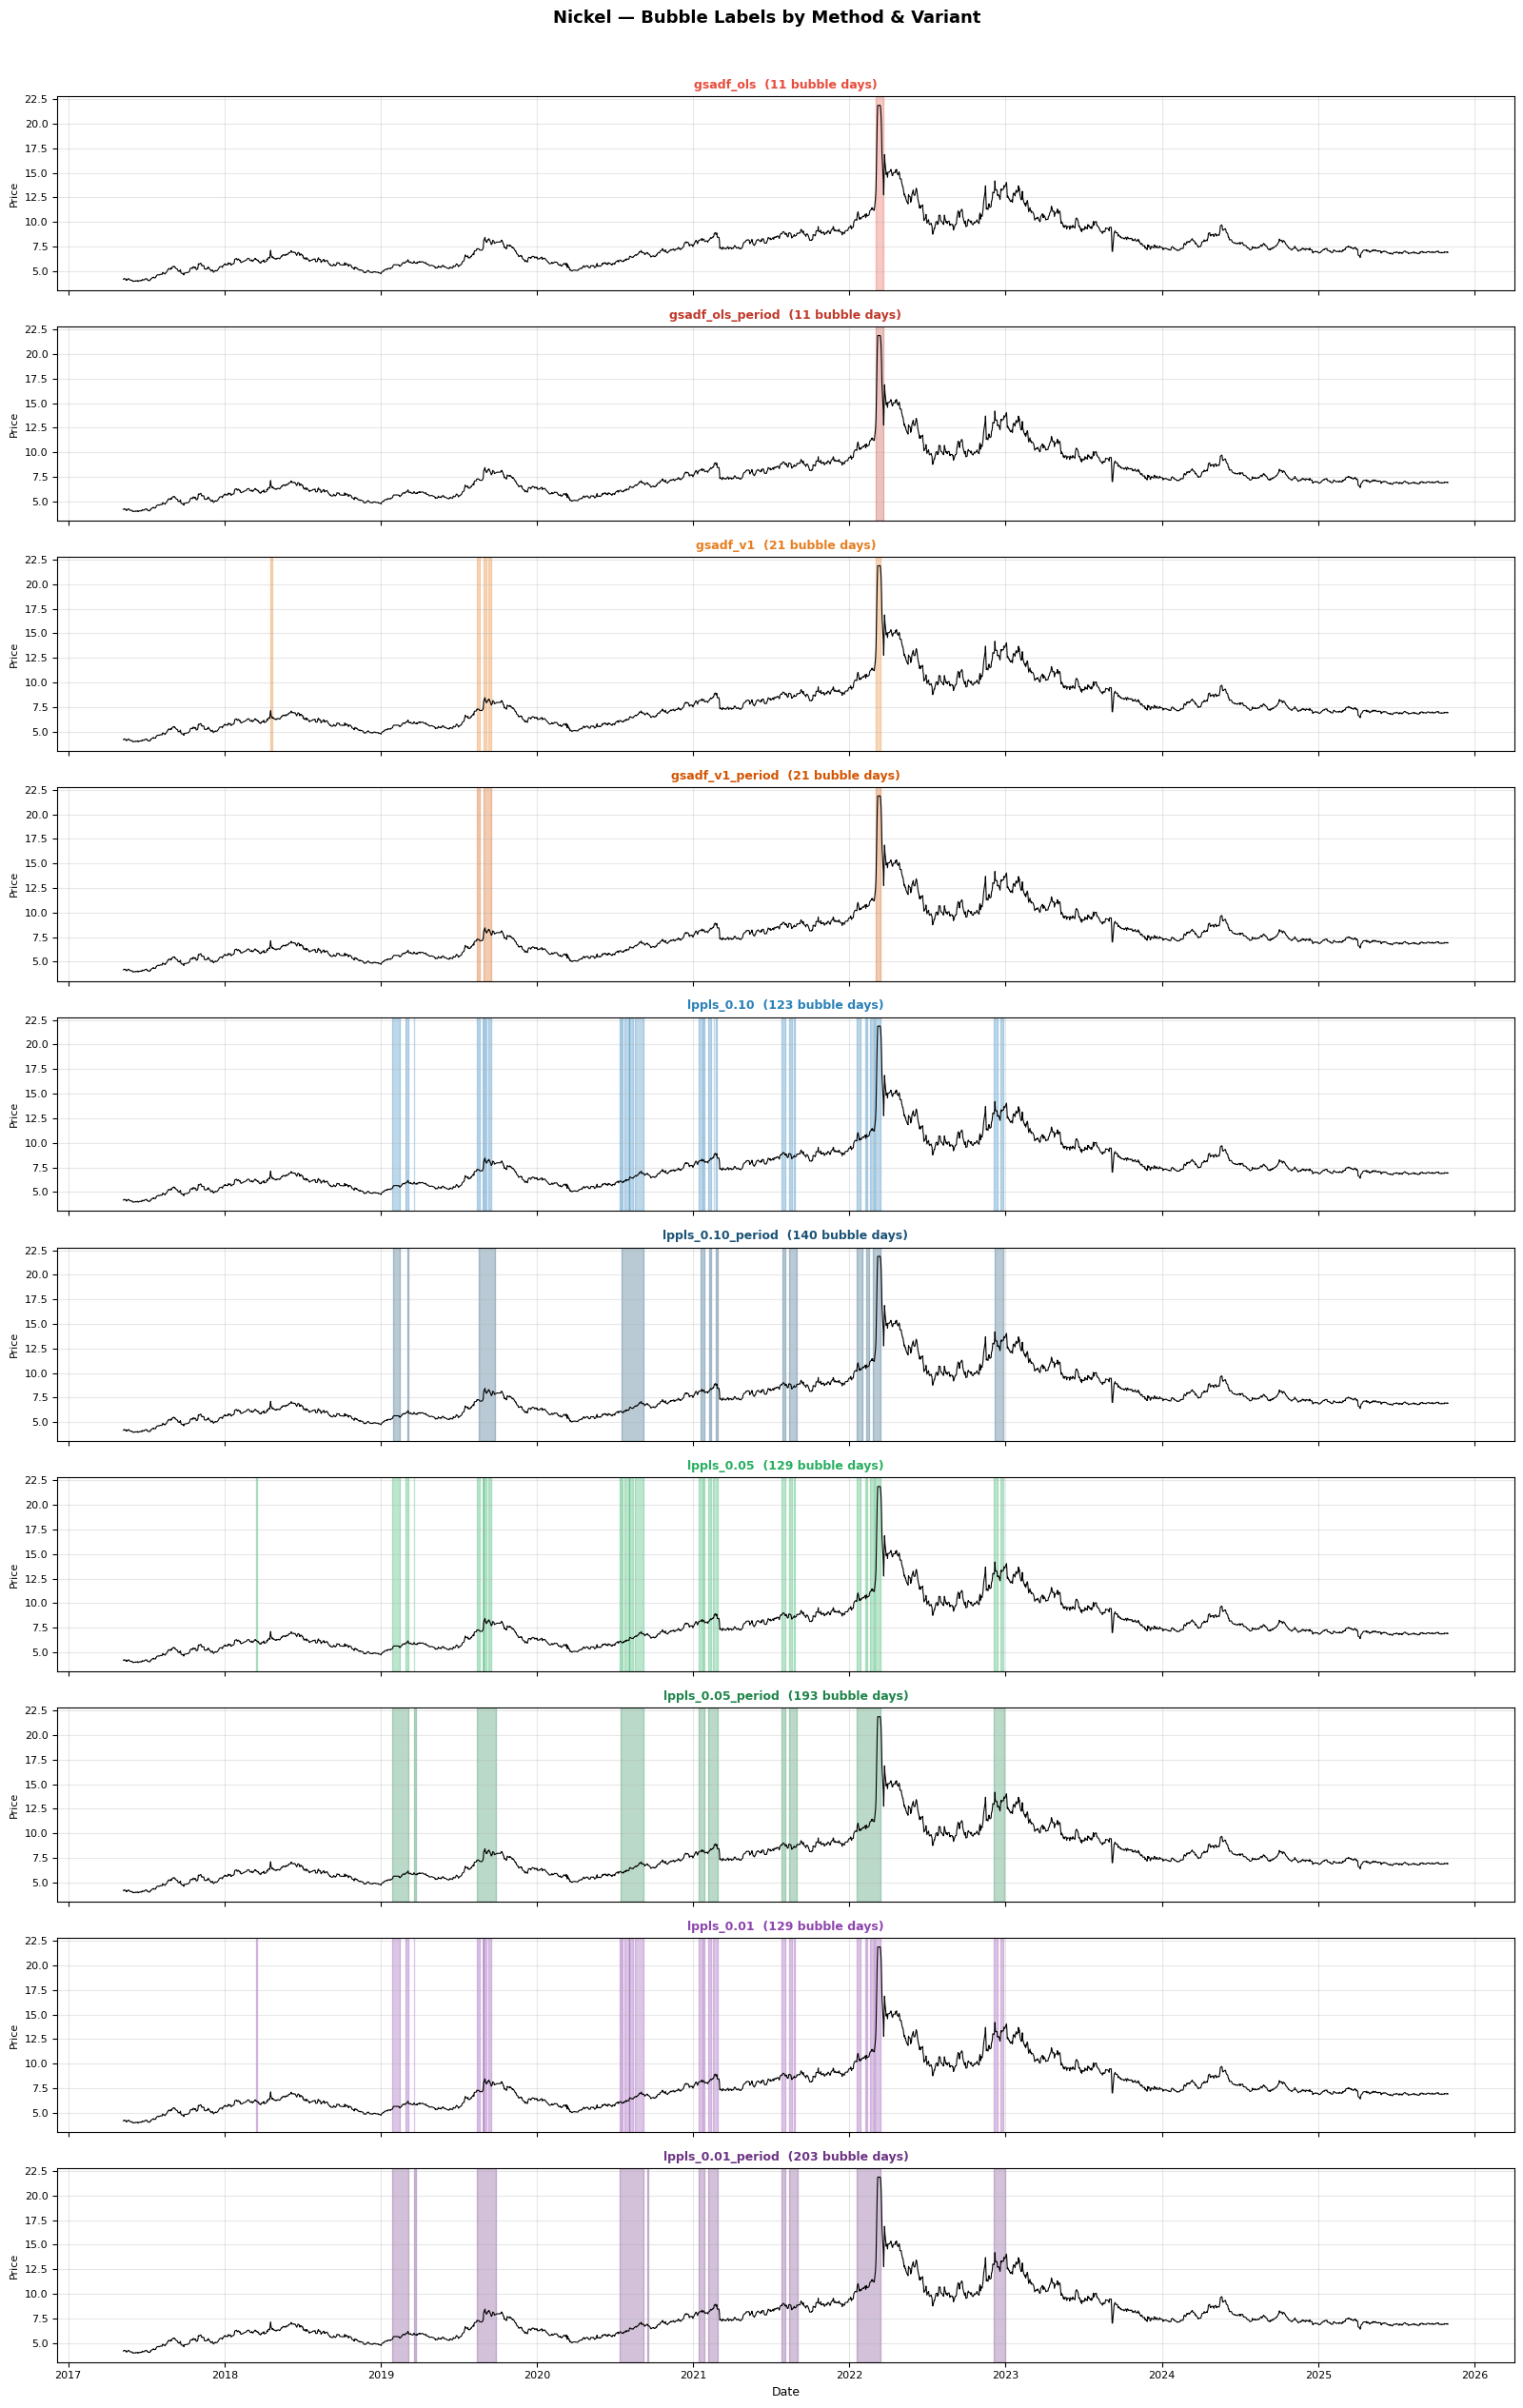

Saved → ../outputs/01_bubble_nickel.png

Done — all 10 label variants generated.


In [6]:
# ── Visual overview: one figure per metal, one row per variant ────────────
# Order: base variant followed immediately by its period version
PLOT_VARIANTS = [
    'gsadf_ols',         'gsadf_ols_period',
    'gsadf_v1',          'gsadf_v1_period',
    'lppls_0.10',        'lppls_0.10_period',
    'lppls_0.05',        'lppls_0.05_period',
    'lppls_0.01',        'lppls_0.01_period',
]
VARIANT_COLORS = {
    'gsadf_ols':         '#e74c3c',
    'gsadf_ols_period':  '#c0392b',
    'gsadf_v1':          '#e67e22',
    'gsadf_v1_period':   '#d35400',
    'lppls_0.10':        '#2980b9',
    'lppls_0.10_period': '#1a5276',
    'lppls_0.05':        '#27ae60',
    'lppls_0.05_period': '#1e8449',
    'lppls_0.01':        '#8e44ad',
    'lppls_0.01_period': '#6c3483',
}

for metal, col in METALS.items():
    n_v  = len(PLOT_VARIANTS)
    fig, axes = plt.subplots(n_v, 1, figsize=(16, 2.5 * n_v), sharex=True)
    dates = output['Date']

    for ax, vname in zip(axes, PLOT_VARIANTS):
        ax.plot(dates, output[col], color='black', lw=0.8)

        label_col = f'{metal}_{vname}'
        n_days = 0
        if label_col in output.columns:
            arr    = output[label_col].values
            n_days = int(arr.sum())
            color  = VARIANT_COLORS[vname]
            in_b   = False
            for i in range(len(arr)):
                if arr[i] == 1 and not in_b:
                    s = dates.iloc[i]; in_b = True
                elif (arr[i] == 0 or i == len(arr) - 1) and in_b:
                    ax.axvspan(s, dates.iloc[i], color=color, alpha=0.3)
                    in_b = False

        ax.set_ylabel('Price', fontsize=8)
        ax.set_title(f'{vname}  ({n_days} bubble days)',
                     fontsize=9, fontweight='bold',
                     color=VARIANT_COLORS.get(vname, 'black'))
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel('Date', fontsize=9)
    plt.suptitle(f'{metal} — Bubble Labels by Method & Variant',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()

    out_path = f'../outputs/01_bubble_{metal.lower()}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved → {out_path}')

print('\nDone — all 10 label variants generated.')
